In [1]:
import os

print(os.getcwd())      # Current working directory
print(os.listdir())     # Files and folders in current directory

C:\Users\bavya\ids_statistical_pre_processing
['.ipynb_checkpoints', 'Untitled.ipynb', 'X_test_clean.csv', 'X_train_clean.csv', 'y_test.csv', 'y_train.csv']


In [2]:
import pandas as pd

X_train = pd.read_csv("X_train_clean.csv")
X_test = pd.read_csv("X_test_clean.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

In [3]:
print("Training Features Shape:", X_train.shape)
print(X_train.head())

Training Features Shape: (148959, 17)
     ip_ttl     ip_id  tcp_flag_syn  tcp_flag_ack  tcp_flag_rst  tcp_flag_fin  \
0  1.178069 -1.206496             0             1             0             0   
1 -0.195203  1.817150             0             1             0             0   
2  1.178069 -1.206496             0             1             0             0   
3 -0.195203  1.630088             0             1             0             0   
4 -0.195203  1.817150             0             1             0             0   

   tcp_flags  tcp_window_size   tcp_seq   tcp_ack  flow_relative_time  \
0          0        -0.324642 -0.805681  0.600360           -0.382441   
1          0        -0.296317 -0.272315  0.868468           -0.382441   
2          0        -0.324642 -0.805681  0.600360           -0.382216   
3          0        -0.346749  0.806394 -1.115865           -0.382441   
4          0        -0.296317 -0.272315  0.868468           -0.382282   

   flow_inter_packet_delay  flow_pac

In [19]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load data
X_train = pd.read_csv("X_train_clean.csv")
X_test = pd.read_csv("X_test_clean.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Random Forest with built-in class balancing
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train
rf.fit(X_train, y_train)

# Predictions
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# Training Performance
print("="*50)
print("TRAINING PERFORMANCE")
print("="*50)
print("Accuracy :", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred, average='weighted'))
print("Recall   :", recall_score(y_train, y_train_pred, average='weighted'))
print("F1 Score :", f1_score(y_train, y_train_pred, average='weighted'))

# Testing Performance
print("\n" + "="*50)
print("TESTING PERFORMANCE")
print("="*50)
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_test_pred, average='weighted'))

# Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_test_pred))

TRAINING PERFORMANCE
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

TESTING PERFORMANCE
Accuracy : 0.5957418318157471
Precision: 0.6044100233495764
Recall   : 0.5957418318157471
F1 Score : 0.5294813188563032

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.31      0.34      0.32      1525
           1       0.10      0.09      0.09      1667
           2       0.62      0.33      0.43      1040
           3       0.86      0.24      0.38      1012
           4       0.75      0.05      0.10      4827
           5       0.10      0.09      0.10      1388
           6       0.57      0.23      0.33      1231
           7       0.67      0.92      0.77     17182

    accuracy                           0.60     29872
   macro avg       0.50      0.29      0.32     29872
weighted avg       0.60      0.60      0.53     29872



In [13]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Load data
X_train = pd.read_csv("X_train_clean.csv")
X_test = pd.read_csv("X_test_clean.csv")

y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# 80-20 split of training data
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Training Shape:", X_train_sub.shape)
print("Validation Shape:", X_val.shape)

# Base model
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Parameter Grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

# Train
grid_search.fit(X_train_sub, y_train_sub)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score:")
print(grid_search.best_score_)

# Best Model
best_rf = grid_search.best_estimator_

# Validation Evaluation
y_val_pred = best_rf.predict(X_val)

print("\n" + "="*50)
print("VALIDATION PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred, average='weighted'))
print("Recall   :", recall_score(y_val, y_val_pred, average='weighted'))
print("F1 Score :", f1_score(y_val, y_val_pred, average='weighted'))

# Test Evaluation
y_test_pred = best_rf.predict(X_test)

print("\n" + "="*50)
print("TEST PERFORMANCE")
print("="*50)

print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_test_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Training Shape: (119167, 17)
Validation Shape: (29792, 17)
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best CV Score:
0.999219069695967

VALIDATION PERFORMANCE
Accuracy : 0.9991272824919442
Precision: 0.9991286267627488
Recall   : 0.9991272824919442
F1 Score : 0.9991269082370935

TEST PERFORMANCE
Accuracy : 0.5986207820032137
Precision: 0.6022820575822614
Recall   : 0.5986207820032137
F1 Score : 0.5387730019942727

Classification Report:
              precision    recall  f1-score   support

           0       0.31      0.40      0.35      1525
           1       0.05      0.05      0.05      1667
           2       0.69      0.38      0.49      1040
           3       0.83      0.23      0.36      1012
           4       0.69      0.06      0.11      4827
           5       0.14      0.13      0.13      1388
           6       0.53      0.

In [20]:
print(rf)
print(hasattr(rf, "classes_"))

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)
True


In [21]:
baseline_train_pred = rf.predict(X_train)
baseline_test_pred = rf.predict(X_test)

tuned_train_pred = best_rf.predict(X_train_sub)
tuned_test_pred = best_rf.predict(X_test)

In [22]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["Baseline RF", "Tuned RF"],
    "Accuracy": [
        accuracy_score(y_test, baseline_test_pred),
        accuracy_score(y_test, tuned_test_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_test_pred, average='weighted'),
        precision_score(y_test, tuned_test_pred, average='weighted')
    ],
    "Recall": [
        recall_score(y_test, baseline_test_pred, average='weighted'),
        recall_score(y_test, tuned_test_pred, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test, baseline_test_pred, average='weighted'),
        f1_score(y_test, tuned_test_pred, average='weighted')
    ]
})

print(comparison.round(4))

         Model  Accuracy  Precision  Recall  F1 Score
0  Baseline RF    0.5957     0.6044  0.5957    0.5295
1     Tuned RF    0.5986     0.6023  0.5986    0.5388


In [23]:
depths = [tree.tree_.max_depth for tree in rf.estimators_]

print("Depth of each tree:")
print(depths)

Depth of each tree:
[24, 24, 20, 23, 27, 27, 25, 28, 22, 26, 25, 21, 27, 21, 19, 24, 28, 26, 23, 27, 22, 26, 25, 24, 25, 23, 26, 26, 23, 22, 22, 24, 28, 21, 25, 28, 25, 23, 21, 24, 28, 23, 23, 28, 24, 28, 22, 25, 27, 23, 24, 27, 25, 24, 20, 31, 24, 26, 25, 25, 27, 23, 25, 29, 28, 25, 24, 23, 26, 25, 30, 22, 30, 22, 29, 29, 24, 25, 24, 22, 26, 24, 23, 22, 23, 23, 25, 27, 25, 21, 24, 25, 25, 23, 23, 23, 25, 27, 26, 25]


In [24]:
import numpy as np

depths = [tree.tree_.max_depth for tree in rf.estimators_]

print("Average Depth:", np.mean(depths))

Average Depth: 24.69


In [25]:
print("Minimum Depth:", min(depths))
print("Maximum Depth:", max(depths))
print("Average Depth:", np.mean(depths))

Minimum Depth: 19
Maximum Depth: 31
Average Depth: 24.69


In [26]:
depths = [tree.tree_.max_depth for tree in best_rf.estimators_]

print("Minimum Depth:", min(depths))
print("Maximum Depth:", max(depths))
print("Average Depth:", np.mean(depths))

Minimum Depth: 19
Maximum Depth: 29
Average Depth: 23.3


In [27]:
print("Configured max_depth:", rf.max_depth)

Configured max_depth: None


In [28]:
print("Configured max_depth:", best_rf.max_depth)

Configured max_depth: None


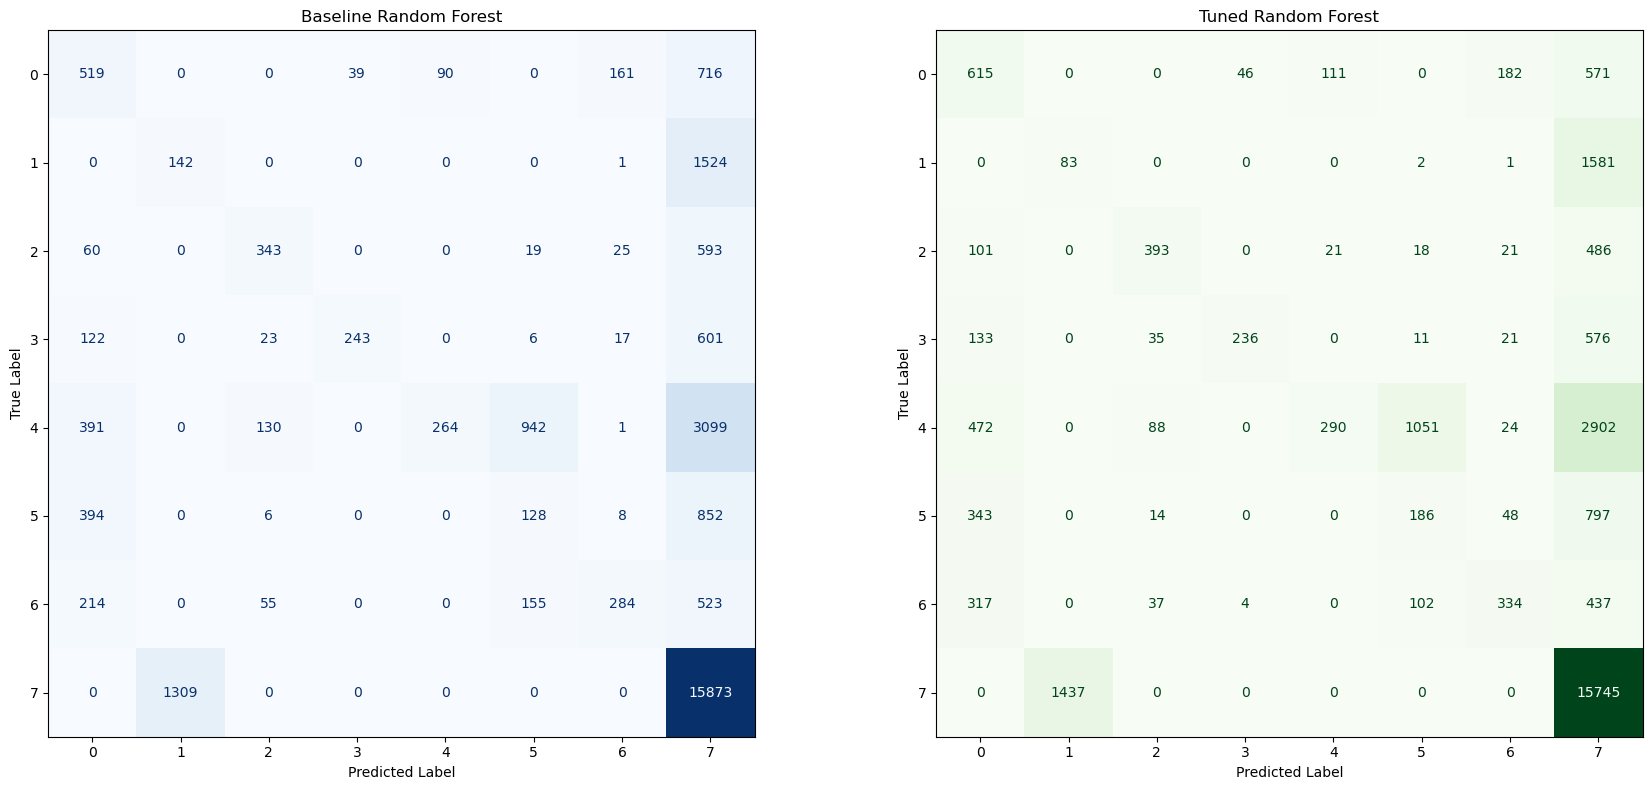

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
baseline_pred = rf.predict(X_test)
tuned_pred = best_rf.predict(X_test)

# Confusion Matrices
cm_baseline = confusion_matrix(y_test, baseline_pred)
cm_tuned = confusion_matrix(y_test, tuned_pred)

# Plot Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Baseline Random Forest
ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=rf.classes_
).plot(
    ax=axes[0],
    cmap="Blues",
    colorbar=False,
    values_format='d'
)

axes[0].set_title("Baseline Random Forest")
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Tuned Random Forest
ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=best_rf.classes_
).plot(
    ax=axes[1],
    cmap="Greens",
    colorbar=False,
    values_format='d'
)

axes[1].set_title("Tuned Random Forest")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [30]:
import pandas as pd
from sklearn.metrics import classification_report

# Predictions
baseline_pred = rf.predict(X_test)
tuned_pred = best_rf.predict(X_test)

# Classification Reports
baseline_report = pd.DataFrame(
    classification_report(y_test, baseline_pred, output_dict=True)
).transpose()

tuned_report = pd.DataFrame(
    classification_report(y_test, tuned_pred, output_dict=True)
).transpose()

precision_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Precision": baseline_report.loc[baseline_report.index[:-3], "precision"].values,
    "Tuned Precision": tuned_report.loc[tuned_report.index[:-3], "precision"].values
})

precision_table = precision_table.round(4)

print("Precision Comparison")
display(precision_table)

recall_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline Recall": baseline_report.loc[baseline_report.index[:-3], "recall"].values,
    "Tuned Recall": tuned_report.loc[tuned_report.index[:-3], "recall"].values
})

recall_table = recall_table.round(4)

print("Recall Comparison")
display(recall_table)

f1_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],
    "Baseline F1-Score": baseline_report.loc[baseline_report.index[:-3], "f1-score"].values,
    "Tuned F1-Score": tuned_report.loc[tuned_report.index[:-3], "f1-score"].values
})

f1_table = f1_table.round(4)

print("F1-Score Comparison")
display(f1_table)

import numpy as np
from sklearn.metrics import accuracy_score

classes = np.unique(y_test)

class_accuracy = []

for cls in classes:
    
    y_true_binary = (y_test == cls).astype(int)

    baseline_binary = (baseline_pred == cls).astype(int)
    tuned_binary = (tuned_pred == cls).astype(int)

    class_accuracy.append([
        cls,
        accuracy_score(y_true_binary, baseline_binary),
        accuracy_score(y_true_binary, tuned_binary)
    ])

accuracy_table = pd.DataFrame(
    class_accuracy,
    columns=[
        "Class",
        "Baseline Accuracy",
        "Tuned Accuracy"
    ]
)

accuracy_table = accuracy_table.round(4)

print("Individual Class Accuracy (One-vs-Rest)")
display(accuracy_table)

comparison_table = pd.DataFrame({
    "Class": baseline_report.index[:-3],

    "Baseline Precision":
        baseline_report.loc[baseline_report.index[:-3], "precision"].values,

    "Tuned Precision":
        tuned_report.loc[tuned_report.index[:-3], "precision"].values,

    "Baseline Recall":
        baseline_report.loc[baseline_report.index[:-3], "recall"].values,

    "Tuned Recall":
        tuned_report.loc[tuned_report.index[:-3], "recall"].values,

    "Baseline F1":
        baseline_report.loc[baseline_report.index[:-3], "f1-score"].values,

    "Tuned F1":
        tuned_report.loc[tuned_report.index[:-3], "f1-score"].values,

    "Baseline Accuracy":
        accuracy_table["Baseline Accuracy"],

    "Tuned Accuracy":
        accuracy_table["Tuned Accuracy"]
})

comparison_table = comparison_table.round(4)

print("Random Forest Baseline vs Tuned - Class-wise Comparison")
display(comparison_table)

Precision Comparison


,Class,Baseline Precision,Tuned Precision
0,0,0.3053,0.3104
1,1,0.0979,0.0546
2,2,0.6158,0.6931
3,3,0.8617,0.8252
4,4,0.7458,0.6872
5,5,0.1024,0.1358
6,6,0.5714,0.5293
7,7,0.6675,0.6817


Recall Comparison


,Class,Baseline Recall,Tuned Recall
0,0,0.3403,0.4033
1,1,0.0852,0.0498
2,2,0.3298,0.3779
3,3,0.2401,0.2332
4,4,0.0547,0.0601
5,5,0.0922,0.1340
6,6,0.2307,0.2713
7,7,0.9238,0.9164


F1-Score Comparison


,Class,Baseline F1-Score,Tuned F1-Score
0,0,0.3219,0.3508
1,1,0.0911,0.0521
2,2,0.4296,0.4891
3,3,0.3756,0.3636
4,4,0.1019,0.1105
5,5,0.0970,0.1349
6,6,0.3287,0.3588
7,7,0.7750,0.7818


Individual Class Accuracy (One-vs-Rest)


,Class,Baseline Accuracy,Tuned Accuracy
0,0,0.9268,0.9238
1,1,0.9051,0.8989
2,2,0.9695,0.9725
3,3,0.9730,0.9723
4,4,0.8442,0.8437
5,5,0.9203,0.9201
6,6,0.9612,0.9600
7,7,0.6915,0.7058


Random Forest Baseline vs Tuned - Class-wise Comparison


,Class,Baseline Precision,Tuned Precision,Baseline Recall,Tuned Recall,Baseline F1,Tuned F1,Baseline Accuracy,Tuned Accuracy
0,0,0.3053,0.3104,0.3403,0.4033,0.3219,0.3508,0.9268,0.9238
1,1,0.0979,0.0546,0.0852,0.0498,0.0911,0.0521,0.9051,0.8989
2,2,0.6158,0.6931,0.3298,0.3779,0.4296,0.4891,0.9695,0.9725
3,3,0.8617,0.8252,0.2401,0.2332,0.3756,0.3636,0.9730,0.9723
4,4,0.7458,0.6872,0.0547,0.0601,0.1019,0.1105,0.8442,0.8437
5,5,0.1024,0.1358,0.0922,0.1340,0.0970,0.1349,0.9203,0.9201
6,6,0.5714,0.5293,0.2307,0.2713,0.3287,0.3588,0.9612,0.9600
7,7,0.6675,0.6817,0.9238,0.9164,0.7750,0.7818,0.6915,0.7058


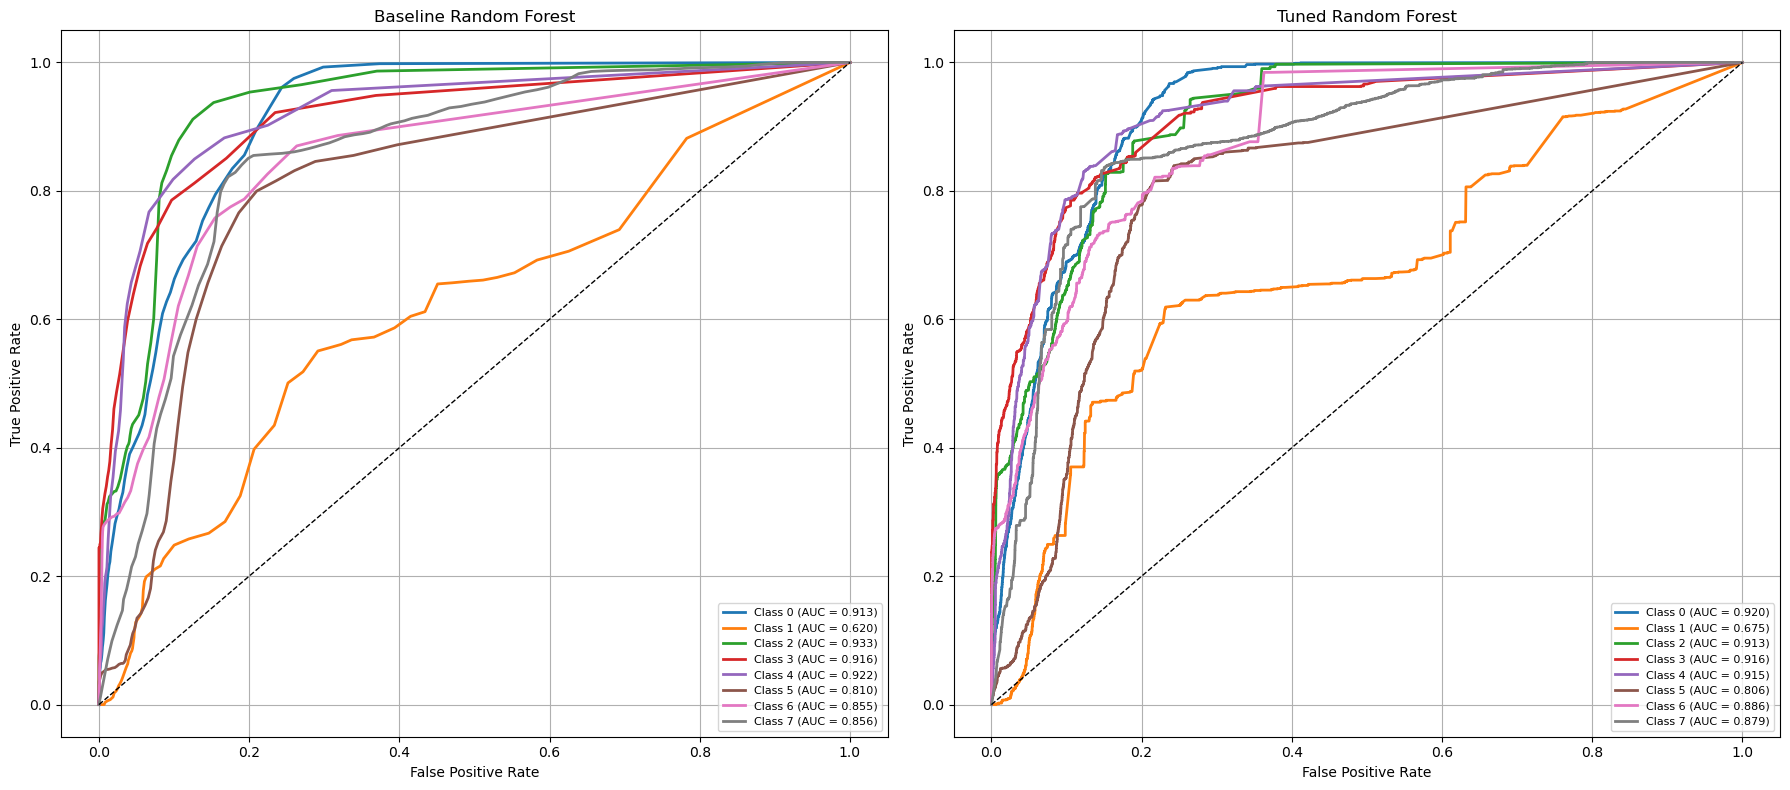

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Classes
classes = np.unique(y_test)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
baseline_prob = rf.predict_proba(X_test)
tuned_prob = best_rf.predict_proba(X_test)

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ---------------- Baseline Random Forest ----------------
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], baseline_prob[:, i])
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title("Baseline Random Forest")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right", fontsize=8)
axes[0].grid(True)

# ---------------- Tuned Random Forest ----------------
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], tuned_prob[:, i])
    roc_auc = auc(fpr, tpr)

    axes[1].plot(
        fpr,
        tpr,
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc:.3f})"
    )

axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title("Tuned Random Forest")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].grid(True)

plt.tight_layout()
plt.show()

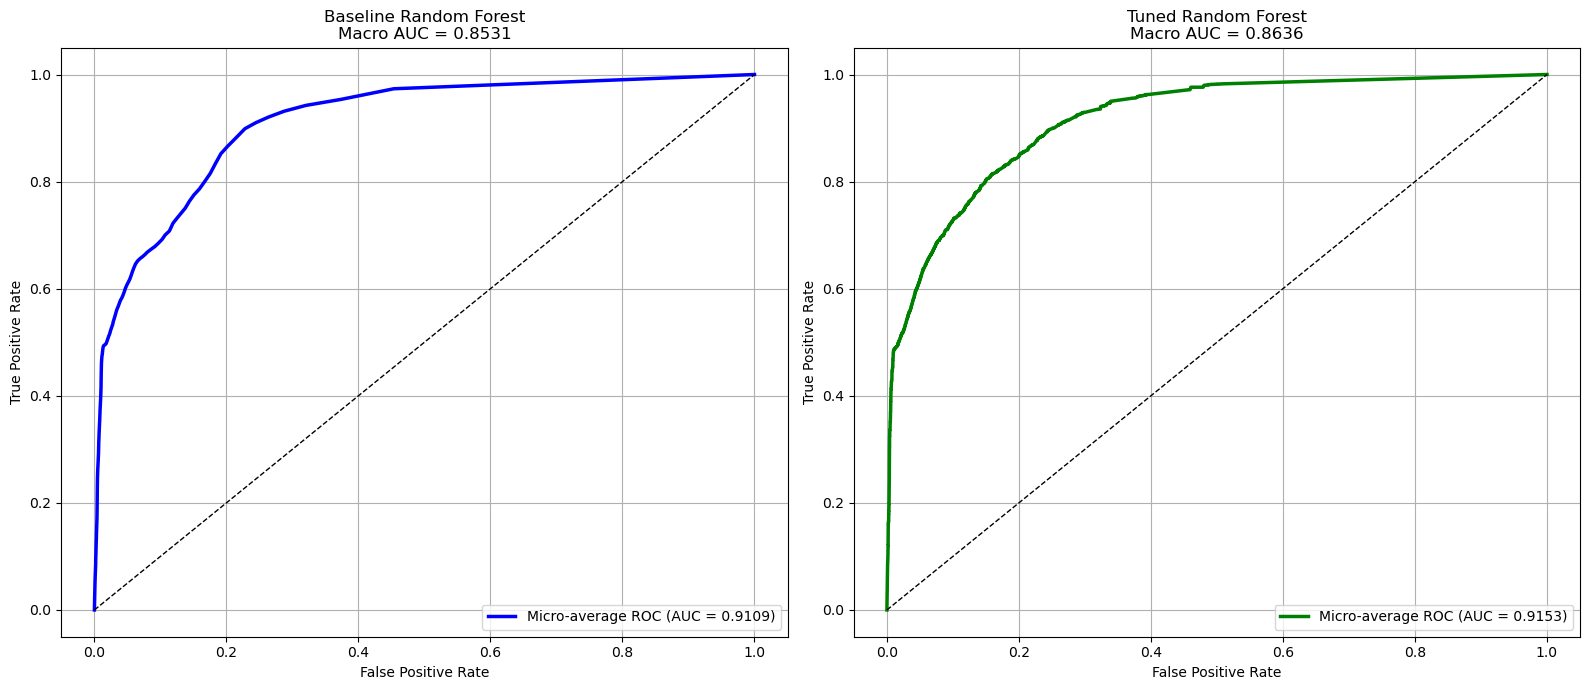

In [34]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import numpy as np

# Classes
classes = np.unique(y_test)

# Binarize the labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predicted probabilities
baseline_prob = rf.predict_proba(X_test)
tuned_prob = best_rf.predict_proba(X_test)

# -----------------------------
# Baseline Random Forest
# -----------------------------
fpr_base, tpr_base, _ = roc_curve(
    y_test_bin.ravel(),
    baseline_prob.ravel()
)

micro_auc_base = auc(fpr_base, tpr_base)

macro_auc_base = roc_auc_score(
    y_test_bin,
    baseline_prob,
    average='macro',
    multi_class='ovr'
)

# -----------------------------
# Tuned Random Forest
# -----------------------------
fpr_tuned, tpr_tuned, _ = roc_curve(
    y_test_bin.ravel(),
    tuned_prob.ravel()
)

micro_auc_tuned = auc(fpr_tuned, tpr_tuned)

macro_auc_tuned = roc_auc_score(
    y_test_bin,
    tuned_prob,
    average='macro',
    multi_class='ovr'
)

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Baseline
axes[0].plot(
    fpr_base,
    tpr_base,
    color='blue',
    linewidth=2.5,
    label=f"Micro-average ROC (AUC = {micro_auc_base:.4f})"
)

axes[0].plot([0,1], [0,1], 'k--', linewidth=1)

axes[0].set_title(f"Baseline Random Forest\nMacro AUC = {macro_auc_base:.4f}")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")
axes[0].grid(True)

# Tuned
axes[1].plot(
    fpr_tuned,
    tpr_tuned,
    color='green',
    linewidth=2.5,
    label=f"Micro-average ROC (AUC = {micro_auc_tuned:.4f})"
)

axes[1].plot([0,1], [0,1], 'k--', linewidth=1)

axes[1].set_title(f"Tuned Random Forest\nMacro AUC = {macro_auc_tuned:.4f}")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc="lower right")
axes[1].grid(True)

plt.tight_layout()
plt.show()